# Feature Extraction - MediaPipe Hand Landmarks

1. Load annotations and frame directories
2. Test extraction on a few gestures
3. Sanity check: draw landmarks on a frame
4. Test normalizing landmarks
5. Test extracting dataset landmarks

## 1. Load data

In [18]:
import sys
sys.path.insert(0, '..')

import numpy as np
from matplotlib import pyplot as plt

from src.data.dataset import load_train_test, find_frames_dirs, find_video_dir, get_frame_paths
from src.data.landmark_extractor import (
    create_hands_detector, extract_landmarks_from_frame, extract_landmarks_from_gesture, normalize_landmarks, extract_dataset_landmarks
)

DATA_DIR = "../raw_data/raw"
train_df, test_df = load_train_test(DATA_DIR)
frame_dirs = find_frames_dirs(DATA_DIR)

Train: 3117 gestures (from 4039 with non-gesture)
Test:  1101 gestures (from 1610 with non-gesture)
Classes: 13 gestures
Found 5 frame directories: ['frames03', 'frames02', 'frames04', 'frames01', 'frames05']


## 2. Test extraction on 5 gestures

In [19]:
# One detector reused across gestures 
det = create_hands_detector()

for i in range(5):
    row = train_df.iloc[i]
    seq, rate = extract_landmarks_from_gesture(
        row['video'], row['start_frame'], row['end_frame'], frame_dirs, det)

    if seq is not None:
        print(f"{row['gesture_name']:12s}  shape {seq.shape}  detection {rate:.0%}")
    else:
        print(f"{row['gesture_name']:12s}  no hand detected")

det.close()

I0000 00:00:1787080456.039432   14113 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1787080456.040348   15802 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: Mesa Intel(R) UHD Graphics (ICL GT1)
W0000 00:00:1787080456.057749   15799 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787080456.082124   15792 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Zoom-out      shape (37, 63)  detection 97%
Point-2f      shape (229, 63)  detection 100%
Throw-down    shape (24, 63)  detection 100%
Point-2f      shape (194, 63)  detection 100%
Throw-left    shape (42, 63)  detection 100%


## 3. Sanity check - landmarks on a single frame
Confirms MediaPipe is actually finding a hand before running the full extraction.

I0000 00:00:1787080474.151230   14113 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1787080474.152436   15825 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: Mesa Intel(R) UHD Graphics (ICL GT1)
W0000 00:00:1787080474.166424   15819 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787080474.185628   15818 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


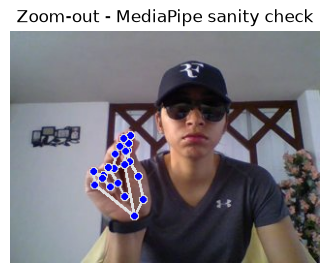

In [20]:
import cv2, mediapipe as mp

sample = train_df.iloc[0]
video_dir = find_video_dir(sample['video'], frame_dirs)
frame_paths = get_frame_paths(video_dir, sample['start_frame'], sample['end_frame'])

# Middle frame of the gesture (hand pose is usually clearest there)
mid_frame = cv2.imread(str(frame_paths[len(frame_paths) // 2]))
mid_frame_rgb = cv2.cvtColor(mid_frame, cv2.COLOR_BGR2RGB)

hands = create_hands_detector(static_mode=True)
results = hands.process(mid_frame_rgb)

annotated = mid_frame_rgb.copy()
if results.multi_hand_landmarks:
    mp.solutions.drawing_utils.draw_landmarks(
        annotated, results.multi_hand_landmarks[0], mp.solutions.hands.HAND_CONNECTIONS)
hands.close()

plt.figure(figsize=(4, 4))
plt.imshow(annotated)
plt.title(f"{sample['gesture_name']} - MediaPipe sanity check")
plt.axis('off')
plt.show()

# 4. Test normalizing landmarks
Checks if the wrist (landmark 0) is on (0, 0) after normalization, and that the z coordinate is left unchanged.

In [21]:
det = create_hands_detector()

sample = train_df.iloc[0]
seq, rate = extract_landmarks_from_gesture(
    sample['video'], sample['start_frame'], sample['end_frame'], frame_dirs, det
)

if seq is not None:
    norm = normalize_landmarks(seq)
    print(f"raw shape: {seq.shape}, normalized shape: {norm.shape}")

    # wrist (landmark 0) should now sit at (0, 0) in x, y for every frame
    wrist_xy = norm.reshape(-1, 21, 3)[:, 0, :2]
    print("wrist x, y after normalization (should be ~0):")
    print(wrist_xy[:3])

    # z should be unchanged from the raw sequence
    z_raw = seq.reshape(-1, 21, 3)[:, :, 2]
    z_norm = norm.reshape(-1, 21, 3)[:, :, 2]
    print("z unchanged:", np.allclose(z_raw, z_norm))

det.close()

I0000 00:00:1787080484.263844   14113 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1787080484.265118   15846 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: Mesa Intel(R) UHD Graphics (ICL GT1)
W0000 00:00:1787080484.294339   15839 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787080484.315213   15840 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


raw shape: (37, 63), normalized shape: (37, 63)
wrist x, y after normalization (should be ~0):
[[0. 0.]
 [0. 0.]
 [0. 0.]]
z unchanged: True


# 5. Test extracting dataset landmarks
Test extract_dataset_landmarks on a small sample.

In [22]:
SUBSET = 20

subset_df = train_df.iloc[:SUBSET].copy()

meta = extract_dataset_landmarks(
    subset_df, frame_dirs, output_dir="../data/landmarks/_test", normalize=True
)

meta.head()

I0000 00:00:1787080511.738506   14113 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1787080511.739405   15877 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: Mesa Intel(R) UHD Graphics (ICL GT1)
Extracting landmarks:   0%|          | 0/20 [00:00<?, ?it/s]W0000 00:00:1787080511.753247   15872 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787080511.770314   15871 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Extracting landmarks: 100%|██████████| 20/20 [00:41<00:00,  2.05s/it]


Done. Extracted 20 gestures, skipped 0 (no hand detected).
Mean detection rate: 98.4%
Metadata saved to: ../data/landmarks/_test/_metadata.csv


,index,label,gesture_name,n_frames_valid,detection_rate,npy_path
0,0,12,Zoom-out,37,0.973684,../data/landmarks/_test/00000_class12.npy
1,1,1,Point-2f,229,1.000000,../data/landmarks/_test/00001_class1.npy
2,2,5,Throw-down,24,1.000000,../data/landmarks/_test/00002_class5.npy
3,3,1,Point-2f,194,1.000000,../data/landmarks/_test/00003_class1.npy
4,4,6,Throw-left,42,1.000000,../data/landmarks/_test/00004_class6.npy
